In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [22]:
import asyncio
from typing import Dict, List, TypedDict, Annotated
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages
import operator
from tavily import TavilyClient
from tavily import AsyncTavilyClient

#### 사용자가 입력한 키워드에 대한 뉴스검색 함수

In [13]:
tavily_client = TavilyClient()

def search_recent_news(keyword):
    """
    This tool interacts with the Tavily AI API to search for recent news articles related to a given keyword.

    Args:
        keyword (str): The keyword or phrase to search for in the news articles.

    Returns:
        list: 
        A list of titles, each containing up to 10 of the most recent news articles related to the keyword.
        - 'title' (str): The title of the news article.

    Example:
        response = search_news("OpenAI")
        # Returns a list of news articles published in the last day related to OpenAI.
    """
    article_info = []

    # 뉴스 기사 제목 수집
    response = tavily_client.search(
        query=keyword,
        max_results=10,
        topic="news",
        days=7
    )
    title_list = [i['title'] for i in response['results']]
    return title_list

In [14]:
test_keyword = "OpenAI"
test_result = search_recent_news(test_keyword)

In [15]:
test_result


['Coalition urges California attorney general to halt OpenAI’s for-profit restructuring - Los Angeles Times',
 'OpenAI Likely To Launch New AI Models Next Week - Deccan Chronicle',
 "OpenAI sues Elon Musk claiming 'bad-faith tactics' - BBC",
 'OpenAI reportedly mulls buying Jony Ive and Sam Altman’s AI hardware startup - TechCrunch',
 "Sam Altman's lawyers roast Elon Musk in scorching new court filing - Business Insider",
 'OpenAI gets ready to launch GPT-4.1 - The Verge',
 "OpenAI countersues Elon Musk in legal dispute over ChatGPT maker's business ambitions - Yahoo Finance",
 'Cracks are forming in Elon Musk’s armor of lies - Electrek',
 "Sam Altman's lawyers roast Elon Musk in scorching new court filing - Yahoo",
 'Daniel Lurie’s tech charm offensive in full swing - Politico']

#### 뉴스 레터 테마 설정 함수

In [11]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-4o-mini", temperature=1)

class NewsletterThemeOutput(BaseModel):
    """Output model for structured theme and sub-theme generation."""
    theme: str = Field(
        description="The main newsletter theme based on the provided article titles."
    )
    sub_themes: list[str] = Field(
        description="List of sub-themes or key news items to investigate under the main theme, ensuring they are specific and researchable."
    )

structured_llm_newsletter = llm.with_structured_output(NewsletterThemeOutput)

system = """
You are an expert helping to create a newsletter. 
Based on a list of article titles provided, your task is to choose a single, 
specific newsletter theme framed as a clear, detailed question that grabs the reader's attention. 

In addition, generate 5 sub-themes that are highly specific, researchable news items or insights under the main theme. 
Ensure these sub-themes reflect the latest trends in the field and frame them as compelling news topics.

The output should be formatted as:
- Main theme (in question form)
- 3-5 sub-themes (detailed and focused on emerging trends, technologies, or insights).

The sub-themes should create a clear direction for the newsletter, avoiding broad, generic topics.
All your output should be in Korean

"""

theme_prompt = ChatPromptTemplate([
    ("system", system),
    ("human", "Article titles: \n\n {article_titles}")
])

newsletter_generator = theme_prompt | structured_llm_newsletter

In [16]:
test_output = newsletter_generator.invoke({"article_titles": test_result})

In [27]:
print(test_output)
print("--------")
print(test_output.theme)
print(test_output.sub_themes)

theme='OpenAI의 미래: 기업 재편성과 법적 다툼이 인공지능 산업에 미치는 영향은?' sub_themes=['OpenAI의 수익 구조 재편: 상장 이후 예상되는 변화와 산업 반응은?', '새로운 AI 모델 출시 전, OpenAI의 전략적 파트너십과 기술적 진전에 대한 전문가 인터뷰', '일론 머스크와의 법적 다툼: OpenAI가 이 사건을 통해 얻고자 하는 것과 관련된 산업 전망', 'Jony Ive와 Sam Altman의 스타트업 인수 가능성: 하드웨어와 소프트웨어의 융합이 OpenAI에 미치는 영향은?', 'OpenAI의 GPT-4.1 출시 준비: 이 모델이 인공지능 기술의 발전에 기여할 수 있는 가능성 분석']
--------
OpenAI의 미래: 기업 재편성과 법적 다툼이 인공지능 산업에 미치는 영향은?
['OpenAI의 수익 구조 재편: 상장 이후 예상되는 변화와 산업 반응은?', '새로운 AI 모델 출시 전, OpenAI의 전략적 파트너십과 기술적 진전에 대한 전문가 인터뷰', '일론 머스크와의 법적 다툼: OpenAI가 이 사건을 통해 얻고자 하는 것과 관련된 산업 전망', 'Jony Ive와 Sam Altman의 스타트업 인수 가능성: 하드웨어와 소프트웨어의 융합이 OpenAI에 미치는 영향은?', 'OpenAI의 GPT-4.1 출시 준비: 이 모델이 인공지능 기술의 발전에 기여할 수 있는 가능성 분석']


In [23]:
def merge_dicts(left: Dict, right: Dict) -> Dict:
    return {**left, **right}

class State(TypedDict):
    keyword: str
    article_titles: List[str]
    newsletter_theme: NewsletterThemeOutput
    sub_theme_articles: Dict[str, List[Dict]]
    results: Annotated[Dict[str, str], merge_dicts]
    messages: Annotated[List, add_messages]

# 사용자 검색 키워드를 입력으로 최근 뉴스 검색 노드
def search_keyword_news(state: State) -> State:
    keyword = state['keyword']
    article_titles = search_recent_news(keyword)
    return {"article_titles": article_titles}

# 테마 생성 노드
def generate_newsletter_theme(state: State) -> State:
    article_titles = state['article_titles']
    newsletter_theme = newsletter_generator.invoke({"article_titles": "\n".join(article_titles)})
    newsletter_theme.sub_themes = newsletter_theme.sub_themes[:5]
    return {"newsletter_theme": newsletter_theme}

# 뉴스 검색 노드
async def search_news_for_subtheme(subtheme):
    async_tavily_cilent = AsyncTavilyClient()
    response = await async_tavily_cilent.search(
        query=subtheme,
        max_results=5,
        topic="news",
        days=1,
        include_images=True,        # 이미지 포함
        include_raw_content=True    # 원본 콘텐츠 포함
    )
    images = response['images']
    results = response['results']

    article_info = []   # sub_theme_articles에 title, image_url, raw_content를 저장장
    for i, result in enumerate(results):
        article_info.append({
            'title': result['title'],
            'image_url': images[i],
            'raw_content': result['raw_content']
        })

    return {subtheme: article_info}

# 서브 테마에 대한 뉴스 검색 실시 노드
async def search_sub_theme_articles(state: State) -> State:
    subthemes = state['newsletter_theme'].sub_themes
    results = await asyncio.gather(*[search_news_for_subtheme(subtheme) for subtheme in subthemes])

    sub_theme_articles = {}
    for result in results:
        sub_theme_articles.update(result)

    return {"sub_theme_articles": sub_theme_articles}

# 본문 작성 함수
async def write_newsletter_section_async(state: State, sub_theme: str) -> Dict:
    articles = state['sub_theme_articles'][sub_theme]

    article_references = "\n".join(
        [f"Title: {article['title']}\nContent: {article['raw_content']}..."
         for article in articles]
    )

    prompt = f"""
    Write a newsletter section for the sub-theme: "{sub_theme}".
    
    Use the following articles as reference and include relevant points from both their titles, images, and content:
    <article>
    {article_references}
    <article/>
    Summarize the key points and trends related to this sub-theme, and ensure you reference the images where they add value to the discussion. 
    Keep the tone engaging and informative for newsletter readers. You should write in Korean
    """

    messages = [HumanMessage(content=prompt)]
    response = await llm.ainvoke(messages)
    return {"results": {sub_theme: response.content}}

# 섹션마다 본문 작성 함수
def write_newsletter_section(state: State, sub_theme: str) -> Dict:
    return asyncio.run(write_newsletter_section_async(state, sub_theme))

# 본문 작성 결과물 통합
def aggregate_results(state: State) -> State:
    theme = state['newsletter_theme'].theme
    combined_newsletter = f"# {theme}\n\n"
    for sub_theme, content in state['results'].items():
        combined_newsletter += f"## {sub_theme}\n{content}\n\n"
    return {"messages": [HumanMessage(content=f"Generated Newsletter:\n\n{combined_newsletter}")]}

# 본문 편집 노드
def edit_newsletter(state: State) -> State:
    theme = state['newsletter_theme'].theme
    combined_newsletter = state['messages'][-1].content

    prompt = f"""
    As an expert editor, review and refine the following newsletter on the theme: {theme}

    {combined_newsletter}

    Please ensure:
    0. Title should be in question form. subtitles are free to make question or just sentence.
    1. Consistent tone and style throughout the newsletter
    2. Smooth transitions between sections
    3. Proper formatting and structure
    4. Clear and engaging language
    5. No grammatical or spelling errors

    Provide the edited version of the newsletter.
    """
    messages = [HumanMessage(content=prompt)]
    writer_llm = ChatOpenAI(model="gpt-4o-mini", temperature=1, max_tokens=8192)
    response = writer_llm.invoke(messages)

    return {"messages": HumanMessage(content=f"Edited Newsletter:\n\n{response.content}")}

In [25]:
# LangGraph 구성

workflow = StateGraph(State)

workflow.add_node("editor", edit_newsletter)
workflow.add_node("search_news", search_keyword_news)
workflow.add_node("generate_theme", generate_newsletter_theme)
workflow.add_node("search_sub_themes", search_sub_theme_articles)
workflow.add_node("aggregate", aggregate_results)

for i in range(5):
    node_name = f"write_section_{i}"
    workflow.add_node(node_name, lambda s, i=i: write_newsletter_section(s, s['newsletter_theme'].sub_themes[i]))

workflow.add_edge(START, "search_news")
workflow.add_edge("search_news", "generate_theme")
workflow.add_edge("generate_theme", "search_sub_themes")

for i in range(5):
    workflow.add_edge("search_sub_themes", f"write_section_{i}")
    workflow.add_edge(f"write_section_{i}", "aggregate")

workflow.add_edge("aggregate", "editor")
workflow.add_edge("editor", END)

graph = workflow.compile()

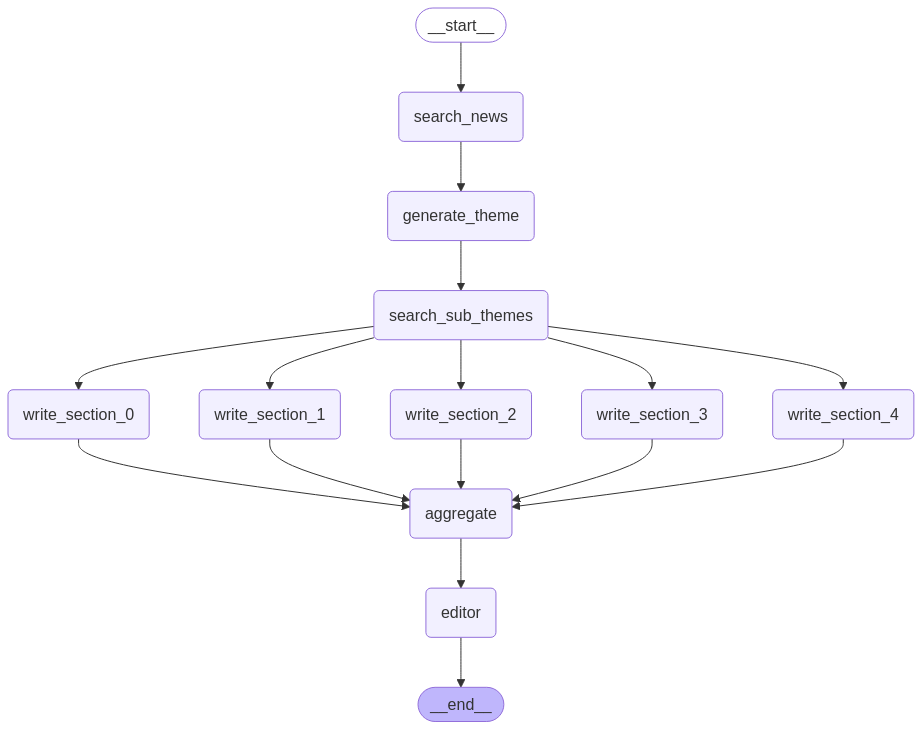

In [26]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
keyword = input("뉴스레터 키워드 입력 :")

inputs = {"keyword": keyword}

async for output in graph.astream(inputs, stream_mode="updates"):
    for key, value in output.items():
        print(f"### Output from node '{key}' :")
        print("--------------------")
        print(print(value))
    print("\n-----------\n")